In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def getNeighbouringIndices(currentIndex, N):
    if currentIndex == 0:
      return [N-1, 1]
    elif currentIndex == (N-1):
      return [N-2, 0]
    else:
      return [currentIndex -1, currentIndex + 1]

In [ ]:
def getEnergyDifference(config, proposedFlipIndex):
  neighbouringIndices = getNeighbouringIndices(proposedFlipIndex, len(config))
  energyDifference = config[neighbouringIndices].sum(dtype=np.int32) \
                    * 2 * config[proposedFlipIndex]
  return energyDifference

In [ ]:
def calclatePairingEnergy(config):
  E = 0
  for i in range(len(config)):
    E = E - config[i] * config[getNeighbouringIndices(i, len(config))[1]]
  return E

In [ ]:
def simulate(N, beta, L, randomSeed = False, H=0):
  if randomSeed:
    config = np.random.choice([-1, 1], size=N)
    # print(config)
  else:
    config = np.ones(N, dtype=np.int32)

  acceptanceProbabilities = [0, 0, 0, 0, np.exp(-4*beta)]

  i = 0
  j = 0

  E = calclatePairingEnergy(config) - H*config.sum()
  EEvolution = []
  timeEvolution = []
  timeSteps = []

  while  i < L:

    proposedFlipIndex = np.random.randint(0, N)

    energyDifference = getEnergyDifference(config, proposedFlipIndex)

    # Reject if energyDifference > 0 & randomComparand > acceptanceProbability
    if energyDifference > 0:
      acceptanceProbability = acceptanceProbabilities[energyDifference]
      randomComparand = np.random.random()
      if randomComparand < acceptanceProbability:
        # print('Current config: ', config)
        # print('Neighbouring spins: ', config[getNeighbouringIndices(proposedFlipIndex, N)])
        # print('proposedFlipIndex: ', proposedFlipIndex)
        # print('energyDifference: ', energyDifference)

        config[proposedFlipIndex] = -1 * config[proposedFlipIndex]
        newConfigE = E + energyDifference
        # print('Current E: ', E)
        # print('new E: ', newConfigE)
        E = newConfigE

    else:
      # print('Current config: ', config)
      # print('Neighbouring spins: ', config[getNeighbouringIndices(proposedFlipIndex, N)])
      # print('proposedFlipIndex: ', proposedFlipIndex)
      # print('energyDifference: ', energyDifference)

      config[proposedFlipIndex] = -1 * config[proposedFlipIndex]
      newConfigE = E + energyDifference
      # print('Current E: ', E)
      # print('new E: ', newConfigE)
      E = newConfigE

    if j%5 == 0:
      timeEvolution.insert(0,np.copy(config))
      timeSteps.insert(0, i)

    # keep track of the energy E at each trial spin flip
    EEvolution.append(E)

    i = i + 1
    j = j + 1

  return timeEvolution, timeSteps, EEvolution

# 1a

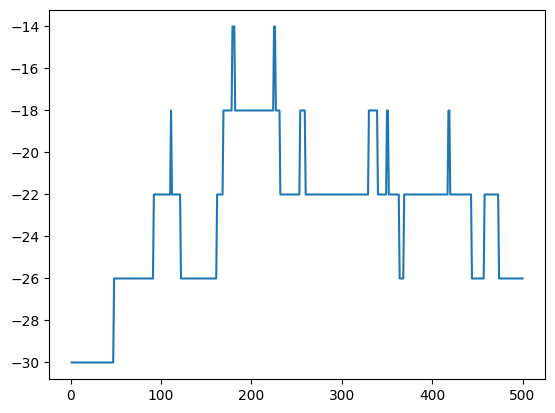

In [ ]:
N = 30
beta = 1
L = 500

timeEvolution, timeSteps, EEvolution = simulate(N, beta, L)
plt.plot(np.arange(1, L+1), EEvolution)

First 25 steps

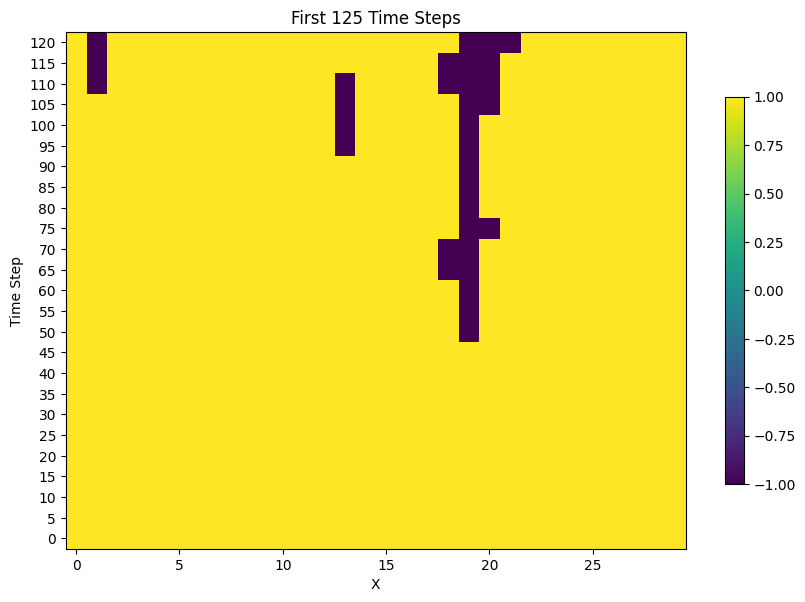

In [ ]:
plt.figure(figsize=(10,10))
plt.matshow(timeEvolution[75:100], fignum=1)
plt.yticks(np.arange(len(timeSteps[75:100])), timeSteps[75:100])
plt.gca().xaxis.set_ticks_position('bottom')
plt.title('First 125 Time Steps')
plt.xlabel('X')
plt.ylabel('Time Step')
plt.colorbar(shrink=0.5)

Second 25 steps

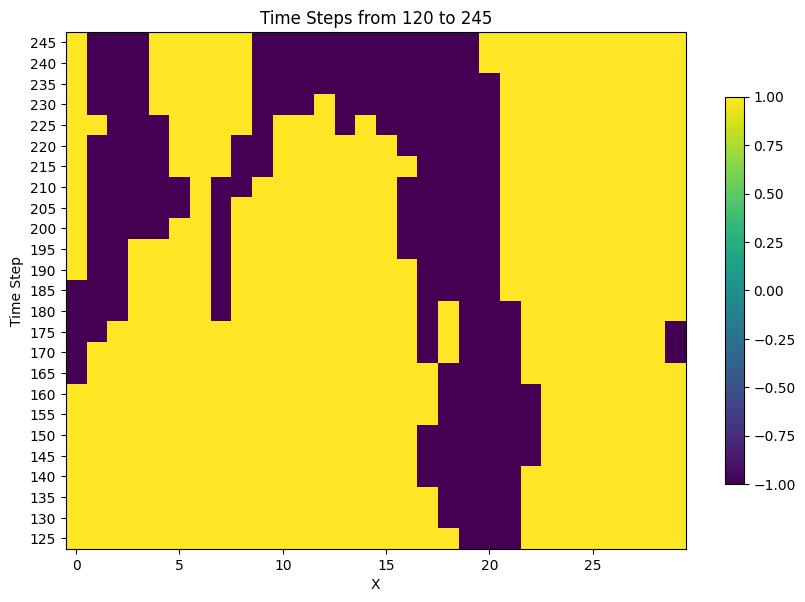

In [ ]:
plt.figure(figsize=(10,10))
plt.matshow(timeEvolution[50:75], fignum=1)
plt.yticks(np.arange(len(timeSteps[50:75])), timeSteps[50:75])
plt.gca().xaxis.set_ticks_position('bottom')
plt.title(f'Time Steps from {timeSteps[75]} to {timeSteps[50]}')
plt.xlabel('X')
plt.ylabel('Time Step')
plt.colorbar(shrink=0.5)

Second-to-last 25 steps

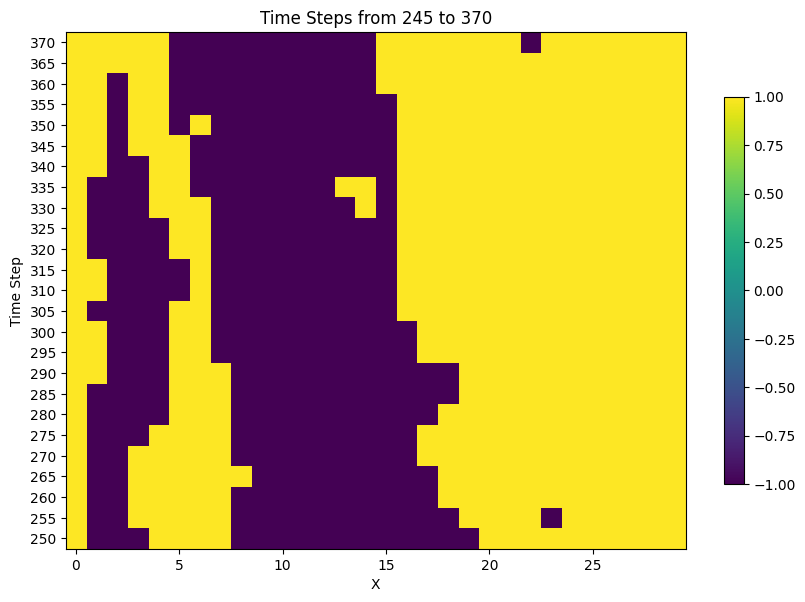

In [ ]:
plt.figure(figsize=(10,10))
plt.matshow(timeEvolution[25:50], fignum=1)
plt.yticks(np.arange(len(timeSteps[25:50])), timeSteps[25:50])
plt.gca().xaxis.set_ticks_position('bottom')
plt.title(f'Time Steps from {timeSteps[50]} to {timeSteps[25]}')
plt.xlabel('X')
plt.ylabel('Time Step')
plt.colorbar(shrink=0.5)

Last 25 steps

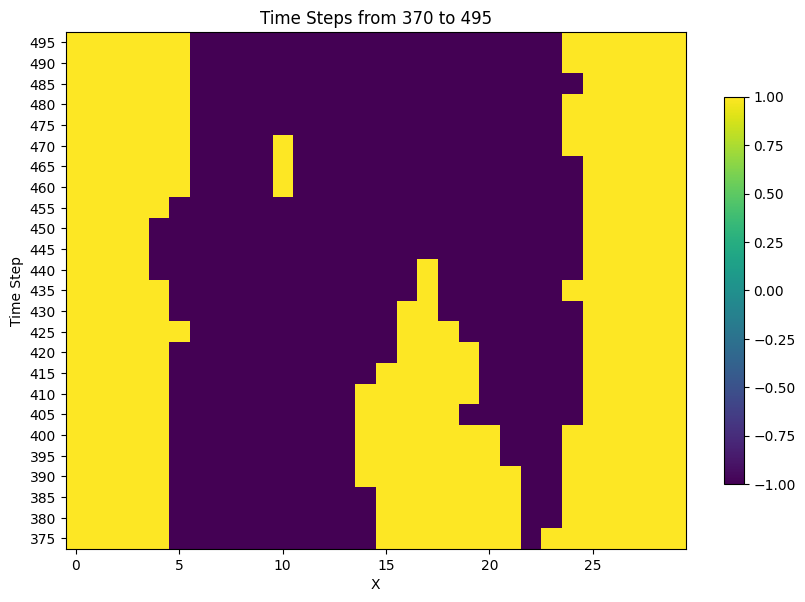

In [ ]:
plt.figure(figsize=(10,10))
plt.matshow(timeEvolution[0:25], fignum=1)
plt.yticks(np.arange(len(timeSteps[0:25])), timeSteps[0:25])
plt.gca().xaxis.set_ticks_position('bottom')
plt.title(f'Time Steps from {timeSteps[25]} to {timeSteps[0]}')
plt.xlabel('X')
plt.ylabel('Time Step')
plt.colorbar(shrink=0.5)

Final State

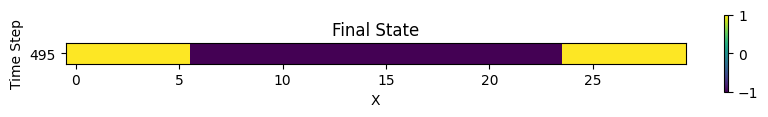

In [ ]:
plt.figure(figsize=(10,10))
plt.matshow(timeEvolution[0:1], fignum=1)
plt.yticks(np.arange(len(timeSteps[0:1])), timeSteps[0:1])
plt.gca().xaxis.set_ticks_position('bottom')
plt.title(f'Final State')
plt.xlabel('X')
plt.ylabel('Time Step')
plt.colorbar(shrink=0.1)

# 1b

In [ ]:
N = 30
L = 5000

beta10 = 10
beta1 = 1
beta01 = 0.1

In [ ]:
timeEvolution10, timeSteps10, EEvolution10 = simulate(N, beta10, L)

In [ ]:
timeEvolution1, timeSteps1, EEvolution1 = simulate(N, beta1, L)

In [ ]:
timeEvolution01, timeSteps01, EEvolution01 = simulate(N, beta01, L)

Text(0, 0.5, 'E')

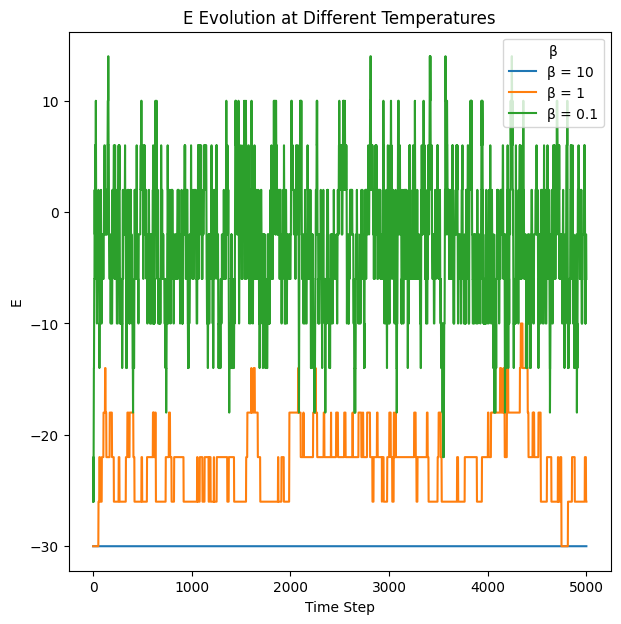

In [ ]:
fig = plt.figure(figsize=(7,7))
t = np.arange(0,L)

plt.plot(t, EEvolution10, label='β = 10')
plt.plot(t, EEvolution1, label='β = 1')
plt.plot(t, EEvolution01, label='β = 0.1')
plt.legend(title='β', loc='upper right')
plt.title(f'E Evolution at Different Temperatures')
plt.xlabel('Time Step')
plt.ylabel('E')

In [ ]:
def simulateMultipleRandomisedLattices(M, N, beta, L, equilibriumTime=0, H=0):
  allEEvolution = []
  allSquaredEEvolution = []
  allFinalMs = 0

  for m in range(M):
    timeEvolution, timeSteps, EEvolution = simulate(
        N,
        beta,
        L,
        True,
        H
    )
    # print(EEvolution)
    # print('config evolution (rev): ', timeEvolution)

    allEEvolution.append(np.array(EEvolution))

    allFinalMs = allFinalMs + allEEvolution[-1].sum()

    sqaredEEvolution = [x**2 for x in EEvolution]
    allSquaredEEvolution.append(sqaredEEvolution)

  allEEvolution = np.array(allEEvolution)
  # print(allEEvolution)
  allSquaredEEvolution = np.array(allSquaredEEvolution)
  EError = []

  averageAllE = []
  averageAllESquared10 = []


  for l in range(equilibriumTime, L):
    averageAllEAtl = np.sum(allEEvolution[:, l])/M
    averageAllE.append(averageAllEAtl)

    averageAllESquaredAtl10 = np.sum(allSquaredEEvolution[:, l])/M
    averageAllESquared10.append(averageAllESquaredAtl10)

    EError.append(np.sqrt((averageAllESquaredAtl10 - averageAllEAtl**2)/M))

  EError = np.array(EError)

  return averageAllE, EError, allFinalMs/M

In [ ]:
M = 100

In [ ]:
t = np.arange(0,L)
averageAllE10, EError10, finalM10 = simulateMultipleRandomisedLattices(M, N, beta10, L)
averageAllE1, EError1, finalM1 = simulateMultipleRandomisedLattices(M, N, beta1, L)
averageAllE01, EError01, finalM01 = simulateMultipleRandomisedLattices(M, N, beta01, L)

Text(0, 0.5, 'E')

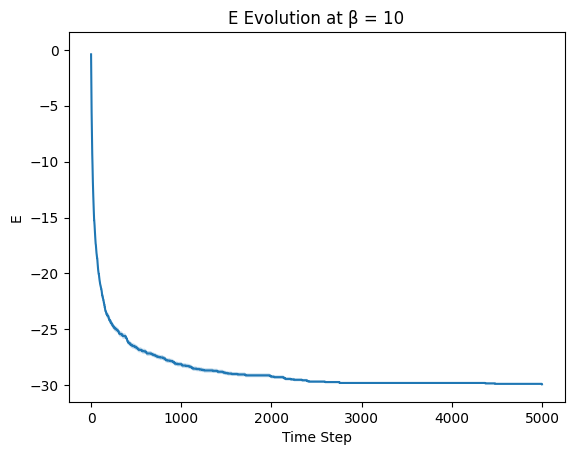

In [ ]:
plt.plot(t, averageAllE10, label='β = 10')
plt.fill_between(
    t,
    averageAllE10 + EError10,
    averageAllE10 - EError10,
    alpha=0.3,
    label='2σ'
)

# plt.legend(title='β', loc='upper right')
plt.title(f'E Evolution at β = 10')
plt.xlabel('Time Step')
plt.ylabel('E')

Text(0, 0.5, 'E')

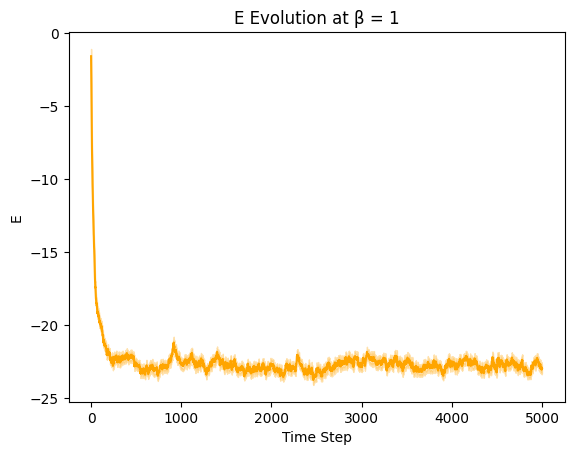

In [ ]:
plt.plot(t, averageAllE1, label='β = 1', color='orange')
plt.fill_between(
    t,
    averageAllE1 + EError1,
    averageAllE1 - EError1,
    alpha=0.3,
    label='Variance',
    color='orange'
)
plt.title(f'E Evolution at β = 1')
plt.xlabel('Time Step')
plt.ylabel('E')

Text(0, 0.5, 'E')

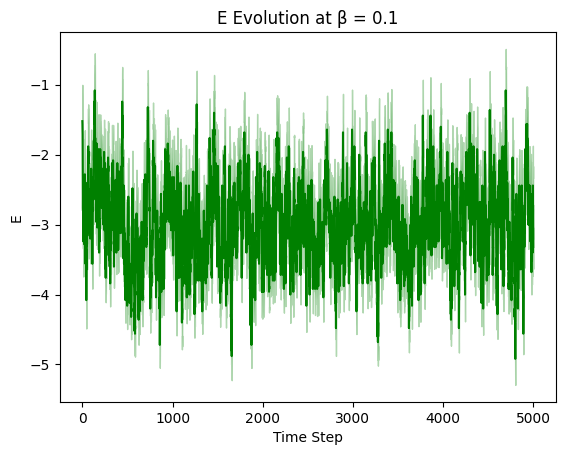

In [ ]:
plt.plot(t, averageAllE01, label='β = 0.1', color='green')
plt.fill_between(
    t,
    averageAllE01 + EError01,
    averageAllE01 - EError1,
    alpha=0.3,
    label='Variance',
    color='green'
)
plt.title(f'E Evolution at β = 0.1')
plt.xlabel('Time Step')
plt.ylabel('E')

Text(0, 0.5, 'E')

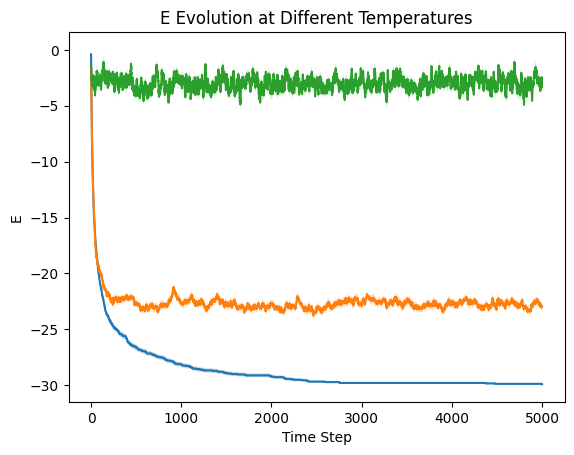

In [ ]:
plt.plot(t, averageAllE10, label='β = 10')
plt.fill_between(
    t,
    averageAllE10 + EError10,
    averageAllE10 - EError10,
    alpha=0.3,
    label='Error'
)

plt.plot(t, averageAllE1, label='β = 1')
plt.fill_between(
    t,
    averageAllE1 + EError1,
    averageAllE1 - EError1,
    alpha=0.3,
    label='Error'
)

plt.plot(t, averageAllE01, label='β = 0.1')
plt.fill_between(
    t,
    averageAllE01 + EError01,
    averageAllE01 - EError01,
    alpha=0.3,
    label='Error'
)

plt.title(f'E Evolution at Different Temperatures')
plt.xlabel('Time Step')
plt.ylabel('E')

# 1c

In [ ]:
equilibriumTime = 1000
Kb = 1.38e-23
betas = np.arange(0.1, 1, 0.1)

averageAllEs = []
allEErrors = []
averageFinalMs = []

theoreticalParticleTimeAveragesE = []

for betai in betas:
  averageAllE, EErrors, averageFinalM = simulateMultipleRandomisedLattices(M, N, betai, L, equilibriumTime, 0.1)
  averageAllEs.append(averageAllE)
  allEErrors.append(EErrors)
  averageFinalMs.append(averageFinalM)

  theoreticalParticleTimeAverageE = -np.tanh(betai)
  theoreticalParticleTimeAveragesE.append(theoreticalParticleTimeAverageE)

In [ ]:
particleTimeAveragesE = []

for averageAllE in averageAllEs:
  timeAverageE = sum(averageAllE) / (L - equilibriumTime)
  particleTimeAverageE = timeAverageE/N

  particleTimeAveragesE.append(particleTimeAverageE)

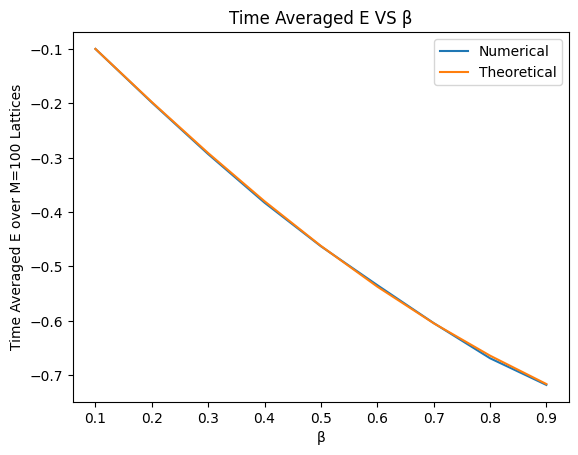

In [ ]:
plt.plot(betas, particleTimeAveragesE, label='Numerical')
plt.plot(betas, theoreticalParticleTimeAveragesE, label='Theoretical')

plt.title(f'Time Averaged E VS β')
plt.xlabel('β')
plt.ylabel('Time Averaged E over M=100 Lattices')
plt.legend(title='', loc='upper right')

# 1d

In [ ]:
CVNs = []
theoreticalCVNs = []

for i in range(len(allEErrors)):
  particleVariance = (allEErrors[i][-1]**2)*M/N
  CVN = (particleVariance / betas[i]**2)

  CVNs.append(CVN)

  theoreticalCVN = betas[i]**2 * (np.cosh(betas[i]))**-2
  theoreticalCVNs.append(theoreticalCVN)

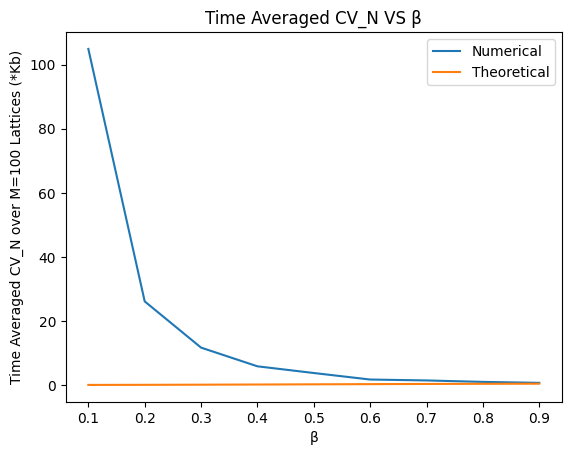

In [ ]:
plt.plot(betas, CVNs, label='Numerical')
plt.plot(betas, theoreticalCVNs, label='Theoretical')
plt.title(f'Time Averaged CV_N VS β')
plt.xlabel('β')
plt.ylabel('Time Averaged CV_N over M=100 Lattices (*Kb)')
plt.legend(title='', loc='upper right')

Text(0, 0.5, 'Averaged M over M=100 Lattices')

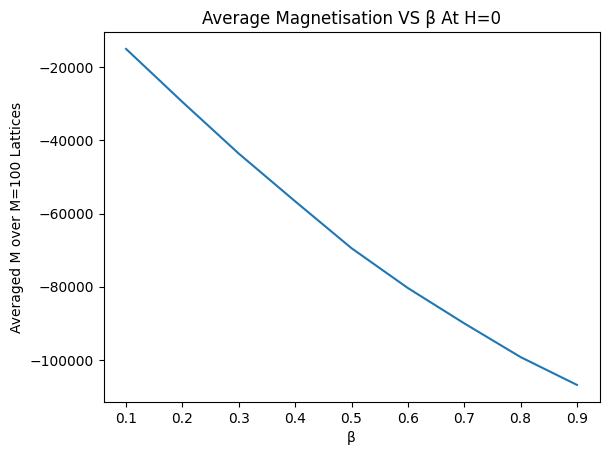

In [ ]:
plt.plot(betas, averageFinalMs)
plt.title(f'Average Magnetisation VS β At H=0')
plt.xlabel('β')
plt.ylabel('Averaged M over M=100 Lattices')
# plt.legend(title='', loc='upper right')